<div style="border-radius:10px; font-size:120%; padding:15px; color:#4D5456; background-color:#E6FEFF">
    
<h1 align="center"><font size=5px; color=#FA2900>Welcome to Online Retail Customers Segmentation and Recommendation System Project!</font></h1>

The motive of this project is to segment **Ecommerce Customers** into meaningful clusters which going to tell us about their transaction activity and let us recommend them products in basis of their needs and activities. Such engagement directly results in increased sales and revenue. Following are the steps in which I will going to conduct **Customer Segmentation**.

- First I will load the data and after loading I will perform **Data Munging** which will help us remove all the unncessary records from data as they will add noise to our Segmentation pipeline as I will discuss later part of this project.

- After performing **Data Munging**, I will develop **Feature Engineering Pipeline** and the framework I will use is **Recency, Frequency and Monetary (RFM)** which is widely used framework for performing Customer Segmentation.

- After developing **Feature Engineering Pipeline** next step involve removing outliers as incorporating them into any Supervised/Unsupervised learning causes the developed model learn noisy pattern thus distorting model's prediction capability.

- After removing outliers, I will Scale the newly generated features as it causes **Principal Component Analysis (PCA)** to be biased towards features with big values which causes our **PCA** to not give **Components**.

- Now I will perform **PCA** to reduce newly generated higher dimension feature space to lower dimension feature space with which we can create impactful and noise-free Clustering with **K-Means Clustering**.

- After conducting **Dimensionality Reduction with PCA**, Now with the help of **Elbow Method** and various Cluster evaluation metrics I will find optimal cluster count foe **K-Means Clustering**.

- Last but not least Now I will interpret Customers activities within each cluster by creating meaningful **Radar Chart** and providing actionable profile summary of customers within each cluster.

After that I will develop **Recommendation System (RecSys)** pipeline which I will explain in second half of this notebook.

<div style="border-radius:10px; font-size:100%; padding:15px; color:#4D5456; background-color:#E6FEFF">
    
<h1 align="center"><font color=#FA2900>Importing Libraries and Loading Data</font></h1>

In [1]:
# Importing the Libraries

import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from scipy.sparse.linalg import svds
from matplotlib.colors import LinearSegmentedColormap
from scipy.stats import percentileofscore, zscore
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.cluster import KMeans
from yellowbrick.cluster import KElbowVisualizer, SilhouetteVisualizer
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from tqdm.notebook import tqdm
import warnings
import random

warnings.filterwarnings("ignore")

In [2]:
# Importing the data

df = pd.read_csv("/kaggle/input/ecommerce-data/data.csv", encoding = "ISO-8859-1")
SHAPE = df.shape
df.head(10)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
5,536365,22752,SET 7 BABUSHKA NESTING BOXES,2,12/1/2010 8:26,7.65,17850.0,United Kingdom
6,536365,21730,GLASS STAR FROSTED T-LIGHT HOLDER,6,12/1/2010 8:26,4.25,17850.0,United Kingdom
7,536366,22633,HAND WARMER UNION JACK,6,12/1/2010 8:28,1.85,17850.0,United Kingdom
8,536366,22632,HAND WARMER RED POLKA DOT,6,12/1/2010 8:28,1.85,17850.0,United Kingdom
9,536367,84879,ASSORTED COLOUR BIRD ORNAMENT,32,12/1/2010 8:34,1.69,13047.0,United Kingdom


<div style="border-radius:10px; font-size:120%; padding:15px; color:#4D5456; background-color:#E6FEFF">

As motive of this analysis is Segmenting customers based on their purchase history if **CustomerID** is **Null**, it will add noise to **KMeans Clustering** and it would not be able to provide meaningful clusters. So I am going to remove all the **CustomerID** records that contain **Null**.

In [3]:
df = df.dropna(subset = "CustomerID")

In [4]:
df.isnull().sum()

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64

In [5]:
# checking the data type of columns

df.dtypes

InvoiceNo       object
StockCode       object
Description     object
Quantity         int64
InvoiceDate     object
UnitPrice      float64
CustomerID     float64
Country         object
dtype: object

<div style="border-radius:10px; font-size:120%; padding:15px; color:#4D5456; background-color:#E6FEFF">

- `InvoiceNo` holds `object` type values as it stores number as well as cancelled orders which are identified by `InvoiceNo` prefixed with `C`.
- `InvoideDate` is `object` type while it stores date with time

In [6]:
print(f"There are {df.InvoiceNo.nunique()} of distinct Invoices")

There are 22190 of distinct Invoices


In [7]:
cancelled_df = df[df["InvoiceNo"].str.startswith("C")]
print(f"{cancelled_df.InvoiceNo.nunique()} \
orders were cancelled in which {len(cancelled_df)} products with worth \
{-sum(cancelled_df['Quantity']*cancelled_df['UnitPrice'])/1000000:.3f}M Sterlings were getting sold. \
It is {len(cancelled_df)*100/len(df):.2f}% of total products.")

3654 orders were cancelled in which 8905 products with worth 0.611M Sterlings were getting sold. It is 2.19% of total products.


In [8]:
df.loc[:, "isCancelled"] = df.loc[:, "InvoiceNo"].str.startswith("C")*1
cancellation_rate = df.groupby("CustomerID")["isCancelled"].transform("mean")*100
del df["isCancelled"]
df.loc[:, "CancellationRate"] = cancellation_rate

CustWhoNeverCancelled = sum(df.groupby("CustomerID")["CancellationRate"].max()==0)
print(f"Among {df['CustomerID'].nunique()} customers, \
{CustWhoNeverCancelled} have never cancelled any product which is \
{CustWhoNeverCancelled*100/df['CustomerID'].nunique():.1f}% of all customers.")

Among 4372 customers, 2783 have never cancelled any product which is 63.7% of all customers.


<div style="border-radius:10px; font-size:120%; padding:15px; color:#4D5456; background-color:#E6FEFF">

Now that I have created `CancellationRate`, I can remove all the rows that have cancellation data. Reason for excluding this rows is that our main motive of this project to segment customer based on their past transacting behaviour but cancelled products only add to noise as cancellation record is not known beforehand of transacting. Thus either performing predictive modelling for `CancellationRate` should be considered or removing such records should be considered.

<div style="border-radius:10px; font-size:120%; padding:15px; color:#4D5456; background-color:#E6FEFF">

For now, I will just remove this records as only **2.2%** of total products were being cancelled and this will going to make very difficult for us to conduct predictive modelling without compromising **Precision** ie. False Positive Rate.

In [9]:
df = df[~df["InvoiceNo"].str.startswith("C")]
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,CancellationRate
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom,4.807692
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,4.807692
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom,4.807692
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,4.807692
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,4.807692


In [10]:
col = "StockCode"
print(f"There are {df[f'{col}'].nunique()} of distinct {col}")
StockWithAlpha = df[~df[f'{col}'].str.isdigit()][f"{col}"].unique()
StockWithMultiAlpha = [i for i in StockWithAlpha if not i[:-1].isdigit() ]
StockWithMultiAlpha

There are 3665 of distinct StockCode


['POST', '15056BL', 'C2', 'M', 'BANK CHARGES', 'PADS', 'DOT']

<div style="border-radius:10px; font-size:120%; padding:15px; color:#4D5456; background-color:#E6FEFF">

Looking into the list of `StockCode` with multiple alphabets, we got to know that there are some `StockCode` that does not follow the same structure (**5** Digits) like most of the `StockCode`. I will remove all the `StockCode` whose length is less than or equal to **4**, as `StockCode` if atleast of length 5. Furthermore **POST**, **BANK CHARGES**, **PADS** and **CRUK** looks like they are not `StockCode`. So they will be removed as well.

In [11]:
StockCodeToRemove = [i for i in StockWithMultiAlpha if len(i)<=4 or i in {"BANK CHARGES", "AMAZONFEE"}]
df = df[~df["StockCode"].isin(StockCodeToRemove)]

<div style="border-radius:10px; font-size:120%; padding:15px; color:#4D5456; background-color:#E6FEFF">

Let's double check whether `StockCodeToRemove` are removed or not.

In [12]:
df[df["StockCode"].isin(StockCodeToRemove)]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,CancellationRate


<div style="border-radius:10px; font-size:120%; padding:15px; color:#4D5456; background-color:#E6FEFF">

Now I would like to investigate `Description`. One thing I notice is that it contain all upper case alphabets so I would like to check for lowercase characters to figure out what product description they are providing.

In [13]:
DescriptionWithLowerCase = df[df["Description"].fillna("N").str.islower()]
DescriptionWithLowerCase

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,CancellationRate


<div style="border-radius:10px; font-size:120%; padding:15px; color:#4D5456; background-color:#E6FEFF">

Now I will look into `InvoiceDate`. It contains datetime values which wil be useful in finding customers temporal activities and many other feature which we will explore in at the time of **Featue Engineering**. So we will keep all the details available in this column.

In [14]:
df["InvoiceDate"] = pd.to_datetime(df.loc[:, "InvoiceDate"])

In [15]:
df.dtypes

InvoiceNo                   object
StockCode                   object
Description                 object
Quantity                     int64
InvoiceDate         datetime64[ns]
UnitPrice                  float64
CustomerID                 float64
Country                     object
CancellationRate           float64
dtype: object

<div style="border-radius:10px; font-size:120%; padding:15px; color:#4D5456; background-color:#E6FEFF">

Let's explore **Numeric** columns of our data. Here my motive is to try to find all the uncesessary and outlier data points so that I can either remove them or find a reason about why its happening.

In [16]:
df[["Quantity", "UnitPrice", "CancellationRate"]].describe().T

,count,mean,std,min,25%,50%,75%,max
Quantity,396370.0,13.046474,180.733597,1.0,2.00,6.000000,12.000000,80995.000000
UnitPrice,396370.0,2.867983,4.264566,0.0,1.25,1.950000,3.750000,649.500000
CancellationRate,396370.0,1.982879,3.676083,0.0,0.00,0.673401,2.439024,71.428571


<div style="border-radius:10px; font-size:120%; padding:15px; color:#4D5456; background-color:#E6FEFF">

Observing upper data, I found out that `Quantity` contains values smaller than **0**, which I assume could mean returned orders also `UnitPrice` has minimum value of **0** which could mean that item is free or data entry error. Both of this cases will going to add noise to our clusters. Due to that reason I thing for time being it is better to drop them. I also noticed that there is significant increase in range from **75th** percentile to **100th** percentile for both `Quantity` and `UnitPrice`. Later on I will handle it by handling outliers as they also distort clusters.

In [17]:
df[df.Quantity<=0].describe().T

,count,mean,min,25%,50%,75%,max,std
Quantity,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
InvoiceDate,0,NaT,NaT,NaT,NaT,NaT,NaT,NaN
UnitPrice,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CustomerID,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CancellationRate,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [18]:
df[df.UnitPrice==0].describe().T

,count,mean,min,25%,50%,75%,max,std
Quantity,33.0,420.515152,1.0,2.0,11.0,36.0,12540.0,2176.713608
InvoiceDate,33,2011-07-09 21:24:10.909091072,2010-12-05 14:02:00,2011-03-30 12:45:00,2011-08-26 14:19:00,2011-11-04 11:55:00,2011-11-25 15:57:00,NaN
UnitPrice,33.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
CustomerID,33.0,14252.575758,12415.0,13081.0,13985.0,14911.0,18059.0,1659.811925
CancellationRate,33.0,5.242491,0.0,0.239808,3.110273,7.352941,32.404181,7.633267


<div style="border-radius:10px; font-size:120%; padding:15px; color:#4D5456; background-color:#E6FEFF">


There are **33** rows which have `Quantity<=0`with pretty huge standard deviation. I will just remove such rows as `Quantity` strictly can not be smaller than **1** when I already have removed cancelled records.

In [19]:
df = df[(df["Quantity"]>0) & (df["UnitPrice"]>0)]
df[["Quantity", "UnitPrice"]].describe().T

,count,mean,std,min,25%,50%,75%,max
Quantity,396337.0,13.012547,179.641245,1.00,2.00,6.00,12.00,80995.0
UnitPrice,396337.0,2.868222,4.264663,0.04,1.25,1.95,3.75,649.5


In [20]:
df.describe(include = "object").T

,count,unique,top,freq
InvoiceNo,396337,18402,576339,541
StockCode,396337,3659,85123A,2035
Description,396337,3871,WHITE HANGING HEART T-LIGHT HOLDER,2028
Country,396337,37,United Kingdom,353985


<div style="border-radius:10px; font-size:120%; padding:15px; color:#4D5456; background-color:#E6FEFF">

Most of the Customers are from `United Kingdom`. In this scenario I would like to include a flag variable `UK_Flag` that will let us know whether customer is from `United Kingdom` or not.

In [21]:
df["Country"].value_counts()[:10]

Country
United Kingdom    353985
Germany             8658
France              8034
EIRE                7136
Spain               2422
Netherlands         2322
Belgium             1935
Switzerland         1810
Portugal            1425
Australia           1181
Name: count, dtype: int64

In [22]:
df.loc[:, "UK_Flag"] = (df["Country"] == "United Kingdom")
df["UK_Flag"] = df["UK_Flag"].map({True:"UK", False:"Outside_UK"})
uk_orders = df.groupby(["UK_Flag"])["UK_Flag"].agg([ "count",  lambda x: (x.count()/len(df))*100])
uk_orders.rename(columns = {"count":"orders", "<lambda_0>":"orders%"}, inplace = True)

df["Sales"] = df["Quantity"] * df["UnitPrice"]
TOTAL_SALES = df["Sales"].sum()

uk_sales = df.groupby(["UK_Flag"])["Sales"].agg(["sum", lambda x: (x.sum() / TOTAL_SALES)*100])
uk_sales.rename(columns = {"sum":"sales", "<lambda_0>":"sales%"}, inplace = True)
del df["Sales"]

In [23]:
ukSaleOrders = pd.merge(uk_orders, uk_sales, left_on = uk_orders.index, right_on = uk_sales.index,)
ukSaleOrders.rename(columns = {"key_0": "country",}, inplace = True)
ukSaleOrders

,country,orders,orders%,sales,sales%
0,Outside_UK,42352,10.685856,1495204.42,17.066466
1,UK,353985,89.314144,7265862.23,82.933534


In [24]:
# Set background color and use dark grid

BG_COLOR = "#E7FEFD"
MISC_COLOR = "#04CDA5"
MISC_COLOR2 = "#05E6FA"

sns.set(rc={"axes.facecolor": BG_COLOR}, style="darkgrid")

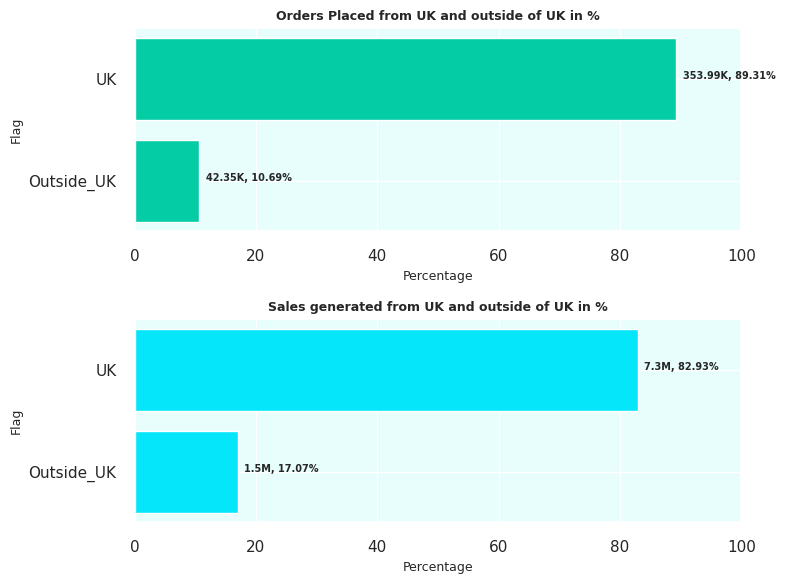

In [25]:
fig, ax = plt.subplots(2, 1, figsize = (8, 6), tight_layout = True)
ax[0].barh(y=ukSaleOrders.country, width=ukSaleOrders["orders%"], color = MISC_COLOR, label = "Orders Percentage")
ax[1].barh(y=ukSaleOrders.country, width=ukSaleOrders["sales%"], color = MISC_COLOR2, label = "Sales Percentage")


for cat, (ordV,ordP) in zip(ukSaleOrders.country, zip(ukSaleOrders["orders"], ukSaleOrders["orders%"])):
    ax[0].text(ordP+1, cat, f"{ordV/1000:.2f}K, {ordP:.2f}%", fontsize = 7, fontweight = "bold")


for cat, (salV,salP) in zip(ukSaleOrders.country, zip(ukSaleOrders["sales"], ukSaleOrders["sales%"])):
    ax[1].text(salP+1, cat, f"{salV/1000000:.1f}M, {salP:.2f}%", fontsize = 7, fontweight = "bold")


ax[0].set_title("Orders Placed from UK and outside of UK in %", fontweight = "bold", fontsize=9)
ax[0].set_xlim([0, 100],)
ax[0].set_xlabel("Percentage", fontsize=9)
ax[0].set_ylabel("Flag", fontsize=9)
#ax[0].legend()

ax[1].set_xlim([0, 100])
ax[1].set_xlabel("Percentage", fontsize = 9)
ax[1].set_ylabel("Flag", fontsize = 9)

ax[1].set_title("Sales generated from UK and outside of UK in %", fontweight = "bold", fontsize=9)
#ax[1].legend()
#plt.tight_layout()
plt.show()

<div style="border-radius:10px; font-size:120%; padding:15px; color:#4D5456; background-color:#E6FEFF">

Looking into the `Bar Plot`, I came to know that about 89% of the orders were placed from `United Kingdom` and the rest (**~11%**) were placed from other Countries. Even though other Counries contribute only `11%` of total orders it is good to see that in sales generated they contribute around **17%**.

In [26]:
df["UK_Flag"] = df["UK_Flag"].map({"UK":1, "Outside_UK":0})

<div style="border-radius:10px; font-size:120%; padding:15px; color:#4D5456; background-color:#E6FEFF">

Now let's look for duplicates in our data. If they were found they will be removed as there is absolutely no reason to store duplicate transactions.

In [27]:
df[df.duplicated()].sort_values(by = ["InvoiceNo", "StockCode", "InvoiceDate"])

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,CancellationRate,UK_Flag
517,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,2010-12-01 11:45:00,1.25,17908.0,United Kingdom,0.0,1
539,536409,22111,SCOTTIE DOG HOT WATER BOTTLE,1,2010-12-01 11:45:00,4.95,17908.0,United Kingdom,0.0,1
527,536409,22866,HAND WARMER SCOTTY DOG DESIGN,1,2010-12-01 11:45:00,2.10,17908.0,United Kingdom,0.0,1
537,536409,22900,SET 2 TEA TOWELS I LOVE LONDON,1,2010-12-01 11:45:00,2.95,17908.0,United Kingdom,0.0,1
598,536412,21448,12 DAISY PEGS IN WOOD BOX,1,2010-12-01 11:49:00,1.65,17920.0,United Kingdom,0.0,1
...,...,...,...,...,...,...,...,...,...,...
541699,581538,22694,WICKER STAR,1,2011-12-09 11:34:00,2.10,14446.0,United Kingdom,0.0,1
541692,581538,22992,REVOLVER WOODEN RULER,1,2011-12-09 11:34:00,1.95,14446.0,United Kingdom,0.0,1
541655,581538,23275,SET OF 3 HANGING OWLS OLLIE BEAK,1,2011-12-09 11:34:00,1.25,14446.0,United Kingdom,0.0,1
541689,581538,23318,BOX OF 6 MINI VINTAGE CRACKERS,1,2011-12-09 11:34:00,2.49,14446.0,United Kingdom,0.0,1


In [28]:
df.drop_duplicates(keep="first", inplace = True)
df[df.duplicated()]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,CancellationRate,UK_Flag


In [29]:
print(f"After finishing preprocessing of our data and removing {SHAPE[0]-len(df)}, we are left with: {len(df)}, {(len(df)/SHAPE[0])*100:.2f}% less number of rows.")

After finishing preprocessing of our data and removing 150759, we are left with: 391150, 72.18% less number of rows.


<div style="border-radius:10px; font-size:120%; padding:15px; color:#4D5456; background-color:#E6FEFF">

<h1 align="center"><font color="#FA2900">Feature Engineering</font></h1>

Now I will develop **Feature Engineering Pipeline**, here my motive is to generate features that will help segment customer based on their Transaction Activity, Region, Interest and Loyalty. For this I will perform most effective feature generation framework for **Customer Segmentation** which is **Recency, Frequency, Monetary (RFM)**. I would like to expand upon **RFM** to make it **Recency, Frequency, Monetary and Miscellaneous (RFMM)**. I would add Miscellaneous feature alongside each of this framework points.

<div style="border-radius:10px; font-size:120%; padding:15px; color:#4D5456; background-color:#E6FEFF">

Let's start **Feature Engineering** by reseting our dataframe indices as after removal of unwanted rows causes our indices to have gaps among them, which is not desirable behaviour.

In [30]:
cleaned_df = df.reset_index(drop = True).copy()
cleaned_df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,CancellationRate,UK_Flag
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,4.807692,1
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,4.807692,1
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,4.807692,1
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,4.807692,1
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,4.807692,1


<div style="border-radius:10px; font-size:120%; padding:15px; color:#4D5456; background-color:#E6FEFF">

<h2 align="center"><font color="red">Recency</font></h2>

By **Recency** we mean all the recent activities of our customers. Some main metrics that help us perform better **Customer Segmentation** is to know what is the last time they have transacted and knowing Customer's Account Age. Some Miscellaenous features includes, `IsWeekend` which tell us about whether transaction will be made on weekend which in turn help us in finding each Customer's transaction activity during weekend which will help us in recommending them products during weekend/workdays.

In [31]:
# Recency

# last time they purchase something
last_date = cleaned_df["InvoiceDate"].max()
cleaned_df.loc[:, "CustomerFirstPurchaseDate"] = cleaned_df.groupby("CustomerID")["InvoiceDate"].transform("min")
cleaned_df.loc[:, "CustomerLastPurchaseDate"] = cleaned_df.groupby("CustomerID")["InvoiceDate"].transform("max")

# Customer's last purchase date - first purchase date
cleaned_df.loc[:, "CustomerAccAge"] = (cleaned_df["CustomerLastPurchaseDate"] - cleaned_df["CustomerFirstPurchaseDate"]).dt.days

cleaned_df.loc[:, "DaysSinceLastPurchase"] = (last_date - cleaned_df["CustomerLastPurchaseDate"]).dt.days

# They bought something int last 30 days?
cleaned_df.loc[:, "LastMonthPurchase"] = (cleaned_df.loc[:, "DaysSinceLastPurchase"]<=30)*1

# Day of Week
cleaned_df.loc[:, "Weekday"] = cleaned_df.loc[:, "InvoiceDate"].dt.dayofweek

# Is Weekend?
cleaned_df.loc[:, "IsWeekend"] = (cleaned_df.loc[:, "Weekday"]>=5)*1
cleaned_df.loc[:, "CustWeekendOrders"] = cleaned_df.groupby("CustomerID")["IsWeekend"].transform("mean")

cleaned_df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,CancellationRate,UK_Flag,CustomerFirstPurchaseDate,CustomerLastPurchaseDate,CustomerAccAge,DaysSinceLastPurchase,LastMonthPurchase,Weekday,IsWeekend,CustWeekendOrders
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,4.807692,1,2010-12-01 08:26:00,2010-12-02 15:27:00,1,371,0,2,0,0.0
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,4.807692,1,2010-12-01 08:26:00,2010-12-02 15:27:00,1,371,0,2,0,0.0
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,4.807692,1,2010-12-01 08:26:00,2010-12-02 15:27:00,1,371,0,2,0,0.0
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,4.807692,1,2010-12-01 08:26:00,2010-12-02 15:27:00,1,371,0,2,0,0.0
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,4.807692,1,2010-12-01 08:26:00,2010-12-02 15:27:00,1,371,0,2,0,0.0


<div style="border-radius:10px; font-size:120%; padding:15px; color:#4D5456; background-color:#E6FEFF">

<h2 align="center"><font color="red">Frequency</font></h2>

**Frequency** is about How Much (Quantity) and in this section I will add all the features that provide information about:
1. `Customer Total Order Placed`, `Customer Total Quantity` and `Average Quantity Per Order`.
2. `Last 30 Days` and `Last 10 orders` bullet point 1 features.
3. Miscellaneous features include
    - `YM` ie. **Year * 100 + Month** to get particular month of a year. This will help us get `Customer Average Monthly Orders`.
    - `Hour` which will help us in creating `Most Active Hour` which help us in enhancing our recomendation pipeline to target them with any promotional offer during their `Most Active Hour` for better engagement.

In [32]:
# Total orders placed by a Customer
cleaned_df.loc[:, "CustomerTotalOrderPlaced"] = cleaned_df.groupby("CustomerID")["InvoiceNo"].transform("nunique")

# Customers total quantity of products bought
cleaned_df.loc[:, "CustomerTotalQuantity"] = cleaned_df.groupby("CustomerID")["Quantity"].transform("sum")

# Mean Quantity per Order
cleaned_df.loc[:, "AvgQuantityPerOrder"] = (
    cleaned_df.groupby("CustomerID")["Quantity"].transform("sum") /
    cleaned_df.groupby("CustomerID")["InvoiceNo"].transform("nunique")
)

# Last purchase quantity
last_purchase_records = cleaned_df[cleaned_df["InvoiceDate"]==cleaned_df["CustomerLastPurchaseDate"]]
cust_last_purchase_quantity_mapping = last_purchase_records.groupby("CustomerID")["Quantity"].sum().to_dict()
cleaned_df.loc[:, "LastPurchaseQuantity"] = cleaned_df["CustomerID"].map(cust_last_purchase_quantity_mapping)

# Last 30 days quantities
cleaned_df.loc[:, "Last30DaysFlag"] = cleaned_df["InvoiceDate"].apply(lambda x: 1 if x+pd.Timedelta(days=30)>=last_date else 0)
cleaned_df.loc[:, "Last30DaysQuantity"] = cleaned_df["Last30DaysFlag"] * cleaned_df["Quantity"]
cleaned_df["Last30DaysQuantity"] = cleaned_df.groupby("CustomerID")["Last30DaysQuantity"].transform("sum")

# last 30 days unique products count
cleaned_df.loc[:, "Last30DaysProds"] = cleaned_df["Last30DaysFlag"] * cleaned_df["StockCode"]
cleaned_df["Last30DaysProds"] = cleaned_df["Last30DaysProds"].replace({0:np.nan})
cleaned_df.loc[:, "Last30DaysUniqueProducts"] = cleaned_df.groupby("CustomerID")["Last30DaysProds"].transform("nunique")


cleaned_df.loc[:, "Last10Orders"] = (
    cleaned_df.groupby("CustomerID")["InvoiceDate"].transform("rank", method = "dense", ascending=False)<=10
)*1 

cleaned_df.loc[:, "Last10OrdersQuantity"] = (cleaned_df.loc[:, "Last10Orders"] * cleaned_df.loc[:, "Quantity"])
cleaned_df.loc[:, "Last10OrdersProducts"] = (cleaned_df.loc[:, "Last10Orders"] * cleaned_df.loc[:, "StockCode"]).replace(0, np.nan)

# last 10 purchases total quantity
cleaned_df.loc[:, "Last10OrdersQuantity"] = cleaned_df.groupby("CustomerID")["Last10OrdersQuantity"].transform("sum")

# last 10 purchases unique products
cleaned_df.loc[:, "Last10OrdersUniqueProducts"] = cleaned_df.groupby("CustomerID")["Last10OrdersProducts"].transform("nunique")

# last 10 purchases total products
cleaned_df.loc[:, "Last10OrdersTotalProducts"] = cleaned_df.groupby("CustomerID")["Last10OrdersProducts"].transform("count")

# Last 10 purchases, Products per purchase
cleaned_df.loc[:, "Last10Orders_ProductsPerOrder"] = cleaned_df.loc[:, "Last10OrdersTotalProducts"] / cleaned_df.loc[:, "Last10OrdersUniqueProducts"]

# Last 10 pruchases, Quantity per purchase
cleaned_df.loc[:, "Last10orders_QuantityPerOrder"] = cleaned_df.loc[:, "Last10OrdersQuantity"] / cleaned_df.loc[:, "Last10OrdersUniqueProducts"]


# Monthly Average Orders placed 
cleaned_df.loc[:, "YM"] = cleaned_df["InvoiceDate"].dt.year * 100 + cleaned_df["InvoiceDate"].dt.month
cust_monthly_orders = cleaned_df.groupby(["CustomerID", "YM"])["InvoiceNo"].nunique().reset_index()
cust_monthly_orders_map = cust_monthly_orders.groupby(["CustomerID"])["InvoiceNo"].mean().to_dict()

cleaned_df.loc[:, "CustomerAverageMonthlyOrders"] =  cleaned_df.loc[:, "CustomerID"].map(cust_monthly_orders_map)

In [33]:
# At what Hour customer make most purchases 
cleaned_df.loc[:, "Hour"] = cleaned_df["InvoiceDate"].dt.hour
cust_hourly_invoice_count = cleaned_df.groupby(["CustomerID", "Hour"])["InvoiceNo"].nunique().reset_index()
#cleaned_df.loc[:, "MostActiveHour"] = cleaned_df.loc[cleaned_df.groupby(["CustomerID", "Hour"])["HourInvoiceCount"].transform("idxmax"), "Hour"].values
cust_most_active_hour_map = cust_hourly_invoice_count.groupby("CustomerID").apply(lambda x: x["Hour"].loc[x["InvoiceNo"].idxmax()]).to_dict()
cleaned_df.loc[:, "MostActiveHour"] = cleaned_df["CustomerID"].map(cust_most_active_hour_map)

<div style="border-radius:10px; font-size:120%; padding:15px; color:#4D5456; background-color:#E6FEFF">

<h2 align="center"><font color="red">Monetary</font></h2>

**Frequency** is about How Much (Sales) and in this section I will add all the features that provide information about:
1. `Customer Total Sales` and `Customer Average Sales Per Order`.
2. `Last 30 Days` and `Last 10 orders` bullet point 1 features.
3. Miscellaneous features include
    - `Customer Average Monthly Sales`.

In [34]:
# Monetary

cleaned_df.loc[:, "TotalSales"] = cleaned_df["Quantity"] * cleaned_df["UnitPrice"]


# Total sales by each customer
cleaned_df.loc[:, "CustomerTotalSales"] = cleaned_df.groupby("CustomerID")["TotalSales"].transform("sum")

# average sales per order
cleaned_df.loc[:, "CustomerAvgSalesPerOrder"] = cleaned_df["CustomerTotalSales"] / cleaned_df["CustomerTotalOrderPlaced"]

# sales generated in last 10 orders
cleaned_df.loc[:, "Last10OrdersSales"] = cleaned_df["Last10Orders"] * cleaned_df["TotalSales"]
cleaned_df.loc[:, "CustomerLast10Orders_Sales"] = cleaned_df.groupby("CustomerID")["Last10OrdersSales"].transform("sum")

# sales generated in last 30 days 
cleaned_df.loc[:, "Last30DaysSales"] = cleaned_df["Last30DaysFlag"] * cleaned_df["TotalSales"]
cleaned_df.loc[:, "CustomerLast10Orders_Sales"] = cleaned_df.groupby("CustomerID")["Last30DaysSales"].transform("sum")

# Average sales generated each Month
cust_monthly_sales = cleaned_df.groupby(["CustomerID", "YM"])["TotalSales"].sum().reset_index()
cust_monthly_sales_map = cust_monthly_sales.groupby(["CustomerID"])["TotalSales"].mean().to_dict()
cleaned_df.loc[:, "CustomerAverageMonthlySales"] =  cleaned_df.loc[:, "CustomerID"].map(cust_monthly_sales_map)

In [35]:
to_remove = [
    "InvoiceNo",
    'StockCode',
    'Description',
    'Quantity',
    'InvoiceDate',
    'UnitPrice', 
    'Country',
    'Weekday',
    "Hour",
    "IsWeekend",
    "Last10OrdersProducts",
    "Last30DaysProds",
    "CustomerFirstPurchaseDate",
    "CustomerLastPurchaseDate",
    "Last10Orders", 
    "Last30DaysFlag", 
    "YM", 
    "TotalSales",
    "Last10OrdersSales",
    "Last30DaysSales",

    "LastPurchaseQuantity"
    
]
cleaned_df.drop(columns = to_remove, axis = 1, inplace = True)

In [36]:
cleaned_df.drop_duplicates(keep = "first", inplace = True)

In [37]:
cleaned_df.describe().T

,count,mean,std,min,25%,50%,75%,max
CustomerID,4334.0,15299.251731,1721.994109,12346.00,13812.250000,15297.500000,16778.750000,18287.000000
CancellationRate,4334.0,2.416727,6.284246,0.00,0.000000,0.000000,1.975345,71.428571
UK_Flag,4334.0,0.903553,0.295237,0.00,1.000000,1.000000,1.000000,1.000000
CustomerAccAge,4334.0,130.286341,132.089593,0.00,0.000000,92.000000,252.000000,373.000000
DaysSinceLastPurchase,4334.0,91.703046,100.177047,0.00,17.000000,50.000000,142.000000,373.000000
LastMonthPurchase,4334.0,0.390632,0.487948,0.00,0.000000,0.000000,1.000000,1.000000
CustWeekendOrders,4334.0,0.132166,0.279714,0.00,0.000000,0.000000,0.088203,1.000000
CustomerTotalOrderPlaced,4334.0,4.245962,7.634989,1.00,1.000000,2.000000,5.000000,206.000000
CustomerTotalQuantity,4334.0,1186.383018,5040.619437,1.00,159.250000,377.500000,989.750000,196844.000000
AvgQuantityPerOrder,4334.0,255.279570,1316.378362,1.00,92.525000,161.000000,271.982143,74215.000000


<div style="border-radius:10px; font-size:110%; padding:15px ; background-color:#E6FEFF">
    
<h1 align="center"><font color="red">Handling Outliers</font></h1>

<div style="border-radius:10px; font-size:120%; padding:15px; color:#4D5456; background-color:#E6FEFF">

So looking at max value of `Quantity`, `UnitPrice` and `CancellationRate`, I have 3 options on how to handle such outliers.
1. Trucating such high values to maximum threshold value.
2. Removing values greater than 3rd Quartile + Inter Quartile Range(IQR) (75th percentile - 25th percentile).
3. We can also detect outliers by using with ZScore.
4. Using Scikit-Learn's Outlier handling models like **Isolation Forest** or **Local Outlier Factor**

<div style="border-radius:10px; font-size:120%; padding:15px; color:#4D5456; background-color:#E6FEFF">

1. **Option 1** can somewhat provide us misleading information as some product's price are very high compared to all other products and some products can be sold in bulk (Very High Quantity) so truncating such products will cause other products which falls in the maximum threshold value/range to be treat as equal to this outliers, which is misleading.
2.  Then I will perform **Option 2** to manually filter out all the records that does not fall into range specified by us with the help of range obtained by percentiles.
3.  Then I will also perform **ZScore** method to find outliers based on their Z units.
4.  After that I will perform **Outlier Dectection** with **Isolation Forest** ie. **Option 4**.
5.  And finally I will select that technique which neither removing large number of records nor removing very low number of records.

<div style="border-radius:10px; font-size:120%; padding:15px; color:#4D5456; background-color:#E6FEFF"> 

<h2 align="center"><font color='red'>3rd Quartile + IQR</font></h2>

In [38]:
UnitPrice_PercValue = np.percentile(df["UnitPrice"], 75) + (np.percentile(df["UnitPrice"], 75) - np.percentile(df["UnitPrice"], 25))
Quantity_PercValue = np.percentile(df["Quantity"], 75) + (np.percentile(df["Quantity"], 75) - np.percentile(df["Quantity"], 25))

print(f"Outerbound value obtained for Quantity is:{Quantity_PercValue: .1f} which is {percentileofscore(df['Quantity'], Quantity_PercValue):.1f} percentile.")
print(f"Outerbound value obtained for UnitPrice is:{UnitPrice_PercValue: .1f} which is {percentileofscore(df['UnitPrice'], UnitPrice_PercValue):.1f} percentile.")

Outerbound value obtained for Quantity is: 22.0 which is 86.1 percentile.
Outerbound value obtained for UnitPrice is: 6.2 which is 90.0 percentile.


<div style="border-radius:10px; font-size:120%; padding:15px; color:#4D5456; background-color:#E6FEFF">

So from `Option 2`, percentile minimum percentile value obtained is 86 which means that I have to remove atleast 14 percent of our records. I think that I should also try to experiment with other methods to figure out what method to use for detecting and removing Outliers.

<div style="border-radius:10px; font-size:120%; padding:15px; color:#4D5456; background-color:#E6FEFF"> 

<h2 align="center"><font color='red'>Z Score</font></h2>

In [39]:
Z = None
threshold = 3

for col in cleaned_df.drop(columns=["CustomerID", "UK_Flag", "MostActiveHour", "CustWeekendOrders"]).columns:
    temp = abs(zscore(cleaned_df[col])) > threshold
    print(f"{col}: {sum(temp)*100/len(cleaned_df):.1f}%")
    if Z is not None:
        Z += temp
    else:
        Z = temp

print()
print(f"With ZScore outlier detection method, if threshold is {threshold} then we have to drop {sum(Z)*100/len(cleaned_df):.1f}% of total records.")

CancellationRate: 2.1%
CustomerAccAge: 0.0%
DaysSinceLastPurchase: 0.0%
LastMonthPurchase: 0.0%
CustomerTotalOrderPlaced: 1.2%
CustomerTotalQuantity: 0.7%
AvgQuantityPerOrder: 0.2%
Last30DaysQuantity: 0.4%
Last30DaysUniqueProducts: 1.2%
Last10OrdersQuantity: 0.8%
Last10OrdersUniqueProducts: 1.7%
Last10OrdersTotalProducts: 0.7%
Last10Orders_ProductsPerOrder: 1.6%
Last10orders_QuantityPerOrder: 0.1%
CustomerAverageMonthlyOrders: 0.8%
CustomerTotalSales: 0.8%
CustomerAvgSalesPerOrder: 0.2%
CustomerLast10Orders_Sales: 0.3%
CustomerAverageMonthlySales: 0.4%

With ZScore outlier detection method, if threshold is 3 then we have to drop 6.6% of total records.


<div style="border-radius:10px; font-size:120%; padding:15px; color:#4D5456; background-color:#E6FEFF">

So with **Z Score** method of removing outliers, even after removing some columns which have more outliers (according to Z units), I still have to remove more than **6%** of total records.

<div style="border-radius:10px; font-size:120%; padding:15px; color:#4D5456; background-color:#E6FEFF"> 

<h2 align="center"><font color='red'>Scikit-Learn's Isolation Forest</font></h2>

In [40]:
iso_forest = IsolationForest()
iso_preds = iso_forest.fit_predict(cleaned_df.drop(columns=["CustomerID"]))
cleaned_df.loc[:, "OutlierScore"] = iso_preds

In [41]:
outliers = cleaned_df["OutlierScore"] == -1
print(f"With IsolationForest {sum(outliers*100/len(cleaned_df)):.1f}% outliers dectected.")

With IsolationForest 6.7% outliers dectected.


<div style="border-radius:10px; font-size:120%; padding:15px; color:#4D5456; background-color:#E6FEFF"> 

So with **Isolation Forest**, I was able to find more than **7%** outliers. **Z Score** is giving me around **6-7%** but we have to exclude some columns from data to conduct **Z Score** outlier detection. Which allows me to select **Isolation Forest** for outlier detection and removal without excluding any columns.

In [42]:
cleaned_df = cleaned_df[cleaned_df["OutlierScore"]==1]
cleaned_df.reset_index(drop = True, inplace = True)
cleaned_df.drop(columns = "OutlierScore", axis = 1, inplace = True)

<div style="border-radius:10px; font-size:120%; padding:15px; color:#4D5456; background-color:#E6FEFF"> 

<h1 align="center"><font color='red'>Correlation Analysis</font></h1>

<div style="border-radius:10px; font-size:120%; padding:15px; color:#4D5456; background-color:#E6FEFF"> 

Since we are done with **Feature Engineering** and **Outlier Detection**, Now I will perform **Correlation Analysis** to know about correlation among each numerical variable which will help us to remove **Highly Correlated Variables** as they provide no significant value in creation of meaningful clusters.

In [43]:
cols = cleaned_df.shape[1]-2
mask = np.ones((cols, cols))
mask = np.triu(mask)

custom_colors = ["#079C8D", "#B9FEFD", "white", "#B9FEFD", "#079C8D"]
cmap = LinearSegmentedColormap.from_list("custom_map", custom_colors, N=128)

<div style="border-radius:10px; font-size:120%; padding:15px; color:#4D5456; background-color:#E6FEFF"> 

<h2 align="center"><font color='red'>Correlation Matrix</font></h2>

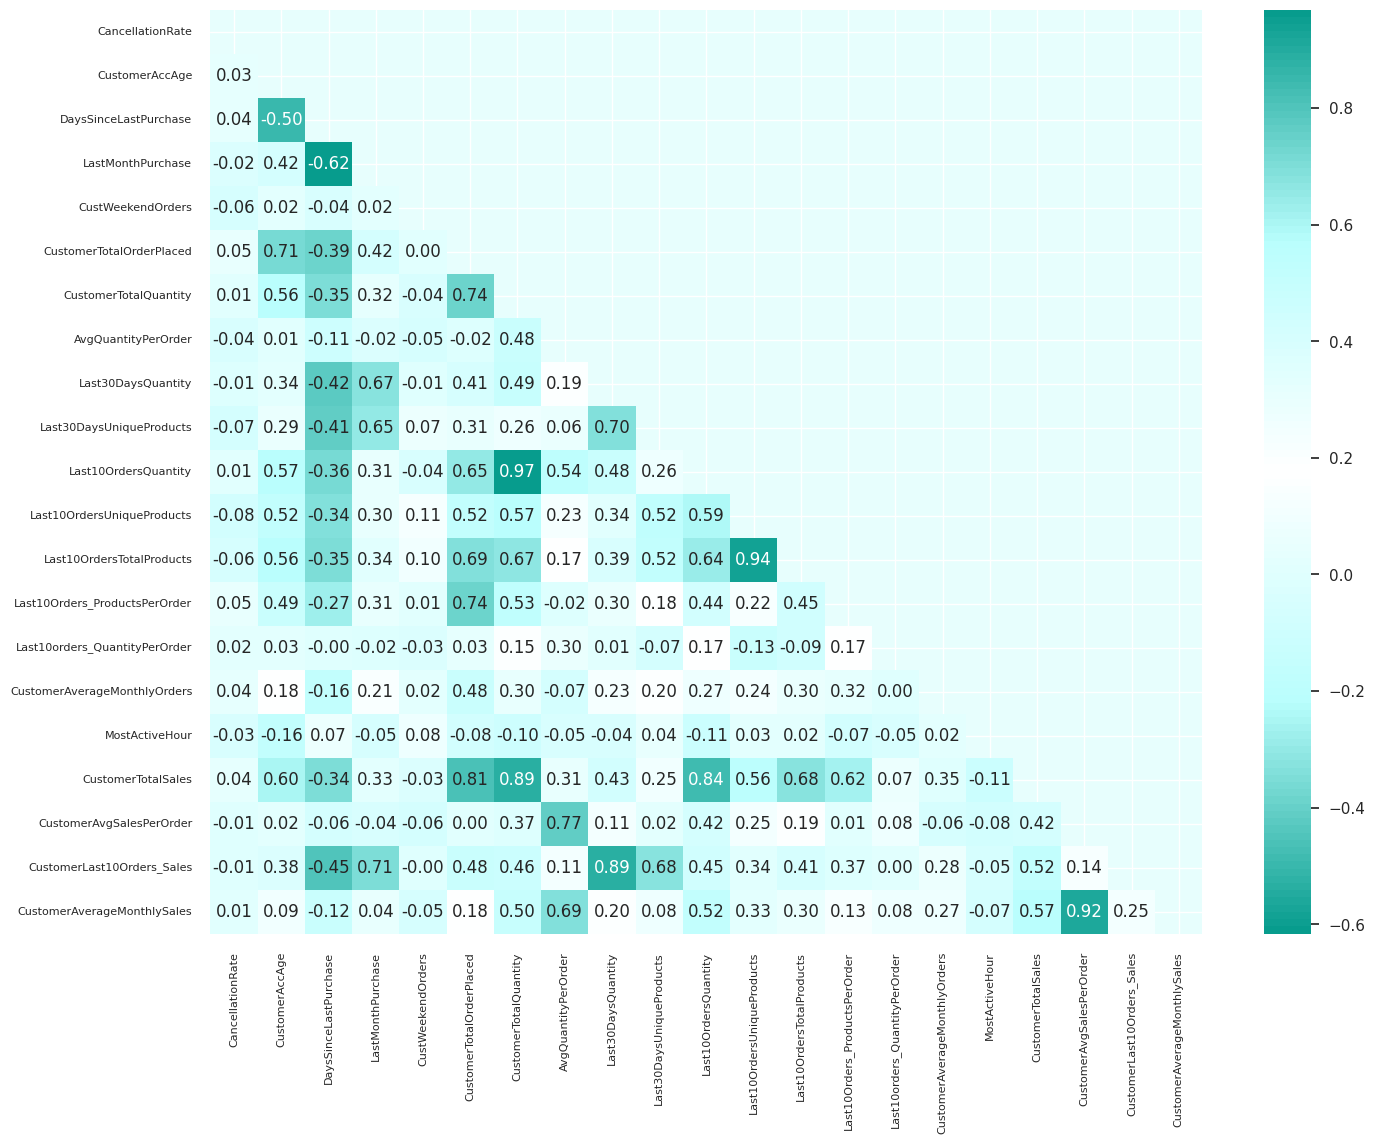

In [44]:
fig, ax = plt.subplots(figsize = (16, 12))
ax = sns.heatmap(cleaned_df.drop(columns=["CustomerID", "UK_Flag"]).corr(), cmap = cmap, mask = mask, annot = True, fmt = ".2f")
ax.tick_params(axis="both", which="major", labelsize = 8)

<div style="border-radius:10px; font-size:120%; padding:15px; color:#4D5456; background-color:#E6FEFF"> 

After viewing **Correlation Matrix**, I got to know that `CustomerAverageMonthlySales` is highly correlated to `CustomerAvgSalesPerOrder`, `Last10OrdersQuantity` is to 
`CustomerTotalQuantity` and `Last10OrdersUniqueProducts` is to `Last10OrdersTotalProducts`. Looking at how highly they are correlated to their corresponding correlated column, I decided to exclude them for further processing.

In [45]:
highly_correlated = ["CustomerAverageMonthlySales", "Last10OrdersQuantity", "Last10OrdersUniqueProducts"]
cleaned_df.drop(columns = highly_correlated, axis = 1, inplace = True)

<div style="border-radius:10px; font-size:120%; padding:15px; color:#4D5456; background-color:#E6FEFF"> 

<h1 align="center"><font color='red'>Feature Scaling with Standard Scaler</font></h1>

<div style="border-radius:10px; font-size:120%; padding:15px; color:#4D5456; background-color:#E6FEFF"> 

Since we are getting close to the process of **Clustering**, **Clustering** methods and the interpretation of cluster requires variables used within clustering to be scaled. Moreover since we have **20+** variables I will perform **Principal Component Analysis (PCA)** which help in `Dimensionality Reduction`. So I will perform feature scaling with `Standard Scaler`.

<div style="border-radius:10px; font-size:120%; padding:15px; color:#4D5456; background-color:#E6FEFF"> 

Now I will create a list that holds all the features that needs to be scaled. **Notice**: we dont need to scale `CustomerID` nor any categorical feature like `UK_Flag` and `Most Active Hour`. But I will include `Most Active Hour` in scaling pipeline as without them being scaled I am not getting desirable results.

In [46]:
to_scale = ['CancellationRate', 'CustomerAccAge',
       'DaysSinceLastPurchase', 'LastMonthPurchase', 'CustWeekendOrders',
       'CustomerTotalOrderPlaced', 'CustomerTotalQuantity',
       'AvgQuantityPerOrder', 'Last30DaysQuantity',
       'Last30DaysUniqueProducts', 'Last10OrdersTotalProducts',
       'Last10Orders_ProductsPerOrder', 'Last10orders_QuantityPerOrder',
       'CustomerAverageMonthlyOrders', 'CustomerTotalSales',
       'CustomerAvgSalesPerOrder', 'CustomerLast10Orders_Sales',
            "MostActiveHour"
]

In [47]:
scaled_df = cleaned_df.copy()

In [48]:
scaler = StandardScaler()
scaled_df.loc[:, to_scale] = scaler.fit_transform(scaled_df.loc[:, to_scale])
scaled_df.head()

,CustomerID,CancellationRate,UK_Flag,CustomerAccAge,DaysSinceLastPurchase,LastMonthPurchase,CustWeekendOrders,CustomerTotalOrderPlaced,CustomerTotalQuantity,AvgQuantityPerOrder,Last30DaysQuantity,Last30DaysUniqueProducts,Last10OrdersTotalProducts,Last10Orders_ProductsPerOrder,Last10orders_QuantityPerOrder,CustomerAverageMonthlyOrders,MostActiveHour,CustomerTotalSales,CustomerAvgSalesPerOrder,CustomerLast10Orders_Sales
0,13047.0,1.765541,1,1.526862,-0.393059,-0.757068,0.189765,1.731304,0.975751,-0.244650,-0.509721,-0.493376,1.322607,0.967028,-0.105780,0.426308,-1.713947,1.707606,0.168125,-0.536254
1,13748.0,-0.382534,1,1.221402,-0.005120,-0.757068,-0.469924,0.513495,-0.249524,-0.659288,-0.509721,-0.493376,-0.482327,-0.123456,-0.013546,1.639261,-1.276535,-0.093020,-0.577493,-0.536254
2,15291.0,0.583114,1,1.769663,-0.701421,1.320886,0.152173,3.253566,1.893097,-0.271413,1.668665,-0.116353,0.451695,2.245758,0.334120,2.700595,-1.276535,2.803831,0.040836,0.686043
3,14688.0,1.181153,1,1.910645,-0.880470,1.320886,-0.469924,5.384732,3.802516,-0.143721,1.228227,1.984200,3.253761,5.716755,-0.060703,1.904595,0.035703,3.557238,-0.243133,1.881559
4,17809.0,0.439776,1,1.840154,-0.800893,1.320886,-0.469924,2.644661,1.835118,-0.139055,0.847307,-0.116353,-0.065804,0.252910,0.419561,1.108594,0.035703,3.425451,0.571952,1.140504


<div style="border-radius:10px; font-size:120%; padding:15px; color:#4D5456; background-color:#E6FEFF"> 
    
<h1 align="center"><font color="red">Principal Component Analysis (PCA)</font></h1>

<div style="border-radius:10px; font-size:120%; padding:15px; color:#4D5456; background-color:#E6FEFF"> 

Now that our Feature Space is scaled, now we can apply **PCA** to reduce our Feature Space to even lower dimension feature space. But to reduce the dimension of feature space I have to perform following tasks beforehand:

- **PCA** needs `n_components` attribute then it will reduce dimensionality to `n_components`.
- To obtain optimal `n_components` we can perform **Elbow Method** to get decent **Explained Variance Ratio** and associated `n_components`.
- Then We can perform **PCA** for dimensionality reduction.

In [49]:
scaled_df.set_index("CustomerID", inplace = True)

In [50]:
variance = []

for c in range(1, 16):
    pca = PCA(n_components = c)
    pca.fit(scaled_df)
    explained_variance = pca.explained_variance_ratio_
    variance.append(sum(explained_variance))

Text(0.5, 1.0, 'Explained Variance by Number of Components')

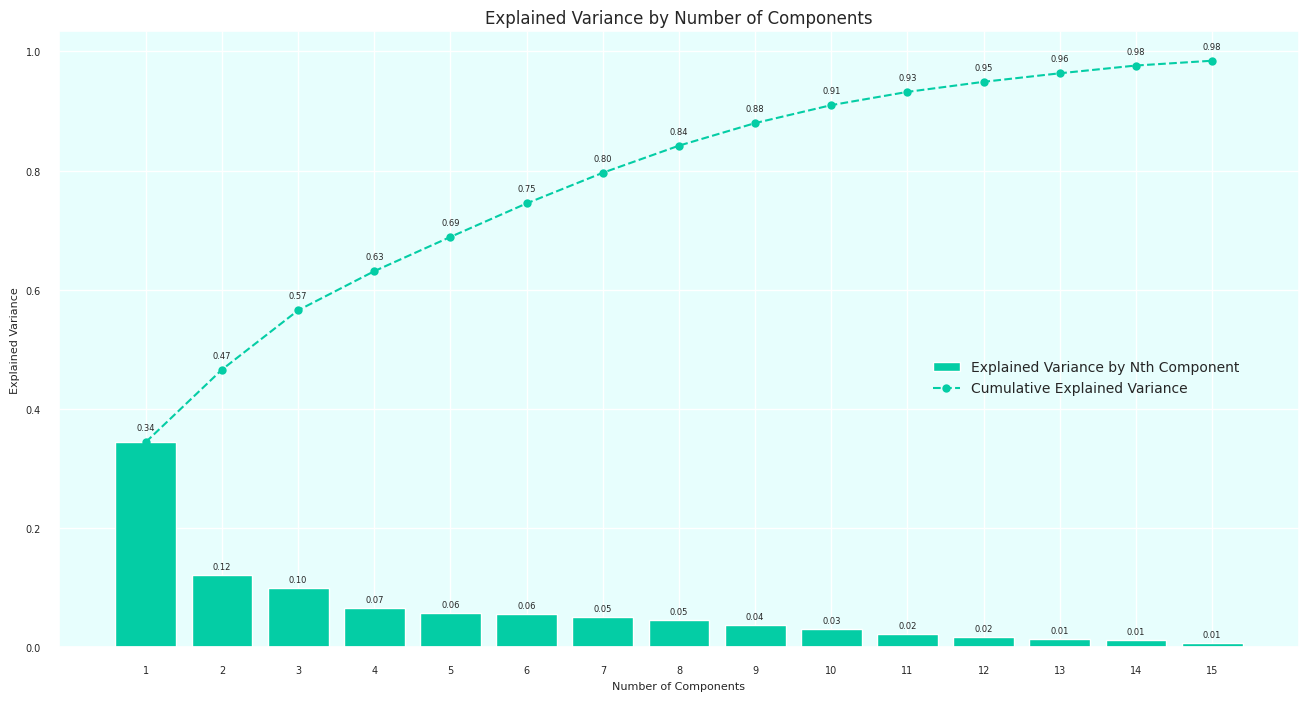

In [51]:
fig, ax = plt.subplots(figsize = (16, 8))

barplot = plt.bar(x = range(1, len(variance)+1), height = explained_variance, color=MISC_COLOR)
lineplot = plt.plot(range(1, len(variance)+1),variance, marker="o", linestyle = "--",color=MISC_COLOR)

plt.xlabel("Number of Components", fontsize=8)
plt.ylabel("Explained Variance", fontsize=8)
plt.xticks(range(1, len(variance)+1))

temp = 0
for i in range(len(variance)):
    plt.text(i+1, variance[i]+.02, f"{variance[i]:.2f}", fontsize=6, ha="center")
    
    if i>0:
        plt.text(i+1, variance[i]-temp+.01, f"{variance[i]-temp:.2f}", fontsize=6, ha="center")
    temp = variance[i]

plt.legend(
    handles = [barplot.patches[0], lineplot[0]],
    labels = ["Explained Variance by Nth Component", "Cumulative Explained Variance"],
    loc = (.7, .4),
    fontsize = 10,
    edgecolor = MISC_COLOR
    
)

plt.tick_params(axis="both", which="major", labelsize=7)
plt.title("Explained Variance by Number of Components",)

<div style="border-radius:10px; font-size:120%; padding:15px; color:#4D5456; background-color:#E6FEFF"> 

Looking at above **Bar Plot and Line Plot**, I will chose **9** as my optimal `n_components` as I want to have more than decent **Explained Variance Ratio** and `n_components`=**9** is explaining upto **88%** variance.

In [52]:
COMPONENTS = 9

pca = PCA(n_components=COMPONENTS)
pca_df = pca.fit_transform(scaled_df)
pca_df = pd.DataFrame(data = pca_df, columns = [f"PCA{c}" for c in range(COMPONENTS)])
pca_df.head()

,PCA0,PCA1,PCA2,PCA3,PCA4,PCA5,PCA6,PCA7,PCA8
0,2.152074,1.339370,-2.822028,-0.876857,-0.984356,-0.758117,1.457161,-0.304948,0.025952
1,-0.201742,-0.220086,-1.779803,-0.806336,-0.618623,0.074317,-0.738173,-1.067994,-1.051973
2,5.589648,0.299769,-2.680139,-1.038614,0.546195,0.030364,-0.003913,-1.485713,-0.622306
3,9.566773,0.403557,-4.184476,0.057713,1.332632,-0.649209,-0.231336,0.243596,1.430567
4,4.576167,0.804000,-1.310530,-0.673730,0.296307,-0.380778,-0.137533,0.277982,-0.514360


<div style="border-radius:10px; font-size:120%; padding:15px; color:#4D5456; background-color:#E6FEFF"> 

<h1 align="center"><font color="red">Clustering with K-Means Clustering</font></h1>

<div style="border-radius:10px; font-size:120%; padding:15px; color:#4D5456; background-color:#E6FEFF"> 

Now that I have created some useful features, removed outliers, scaled features and applied **PCA** for dimensionality reducion next steps in our pipeline is to conduct clustering with available Clustering methods like: **K-Means**, **DBSCAN** and **OPTICS**. Here I would chose **K-Means** clustering method for its efficiency and for its robust approach to cluster datapoints.

<div style="border-radius:10px; font-size:120%; padding:15px; color:#4D5456; background-color:#E6FEFF"> 

To conduct **K-Means** clustering we require `n_clusters` which tell **K-Means** that we want this many clusters. But is many optical ways which require **Cluster Evaluation Metrics** like **Silhouette Score**, **Distortion Score**, **Calinski-Herbasz Score**, **Davies-Bouldin Score** etc. to evaluate the quality of created clusters. So I will Use all this metrics to get optimal `n_clusters`. Although my preference for `n_clusters` is between **3-5**.

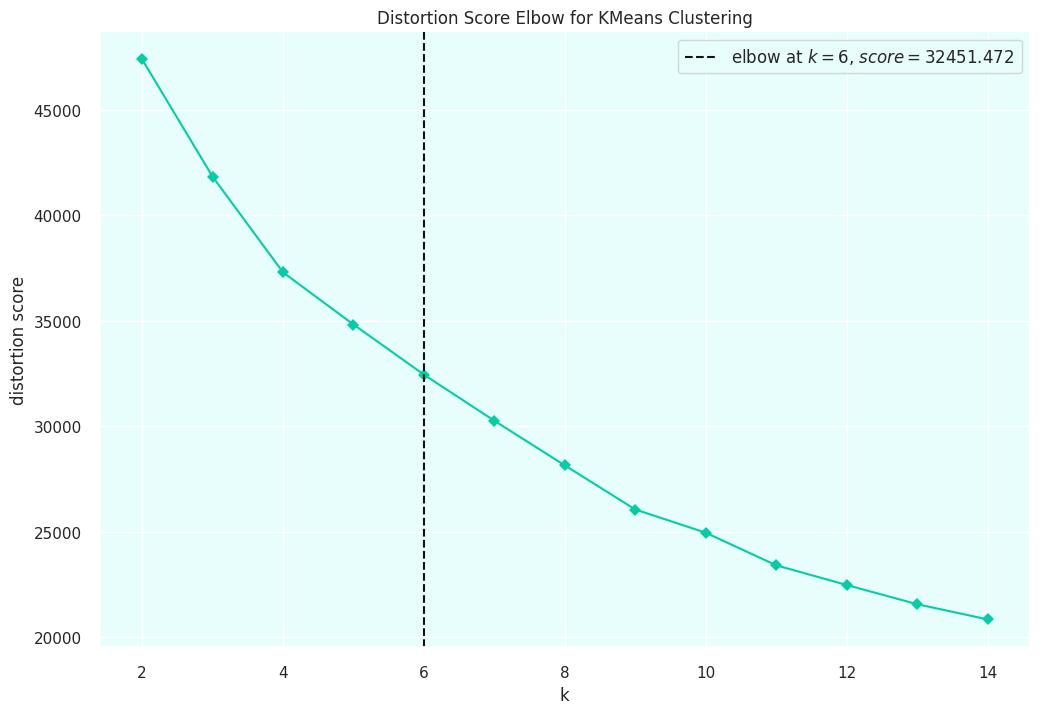

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [53]:
sns.set(style="darkgrid", rc={"axes.facecolor":BG_COLOR})
sns.set_palette([MISC_COLOR])

kmeans = KMeans(init="k-means++", n_init=20, max_iter=300, random_state=44)

fig, ax = plt.subplots(figsize = (12,8))
kelbow = KElbowVisualizer(kmeans, k=(2, 15), ax=ax, timings=False)
kelbow.fit(pca_df)
kelbow.show()

<div style="border-radius:10px; font-size:120%; padding:15px; color:#4D5456; background-color:#E6FEFF"> 
<h2 align="center"><font color="red">Cluster Evaluation Metrics: Silhouette, Calinski-Herbasz and Davies-Bouldin Score</font></h2>

In [54]:
silhouette = []
calinski = []
davies = []

for idx in range(2, 15):
    kmeans = KMeans(n_clusters=idx,init="k-means++", n_init=20, max_iter=300, random_state=44)
    kmeans.fit(pca_df)
    clusters = kmeans.predict(pca_df)
    silhouette.append(silhouette_score(pca_df, clusters))
    calinski.append(calinski_harabasz_score(pca_df, clusters))
    davies.append(davies_bouldin_score(pca_df, clusters))

<div style="border-radius:10px; font-size:120%; padding:15px; color:#4D5456; background-color:#E6FEFF"> 

`getClusterMetricPlot` will give us `Bar Plot` for each of our **Cluster Evaluation Metric**, and by observing them can help us arrive at optimal `n_clusters`.

In [55]:
def getClusterMetricPlot(scores, metric="Silhouette", mode="max"):
    fig, ax1 = plt.subplots(figsize = (8, 6))
    ax1.bar(x=range(2, 15), height=scores,)
    offset = min(score) * .01
    
    for x in range(len(score)):
        
        if mode=="max":
            color = "red" if score[x] == max(scores) else "black"
            fontweight = "bold" if score[x] == max(scores) else "normal"
        else:
            color = "red" if score[x] == min(scores) else "black"
            fontweight = "bold" if score[x] == min(scores) else "normal"

        ax1.text(x+2, score[x]+offset, f"{score[x]:.2f}", ha="center", fontsize=7, color= color,fontweight=fontweight)
        
    plt.title(f"{metric} Score by Number of Clusters", fontsize=10)
    plt.tick_params(axis="both", which="major", labelsize=8)
    
    plt.xlabel("Number of Clusters", fontsize=9)
    plt.ylabel(f"{metric} Score", fontsize=9)

    plt.xticks(range(2,15))
    
    fig.show()

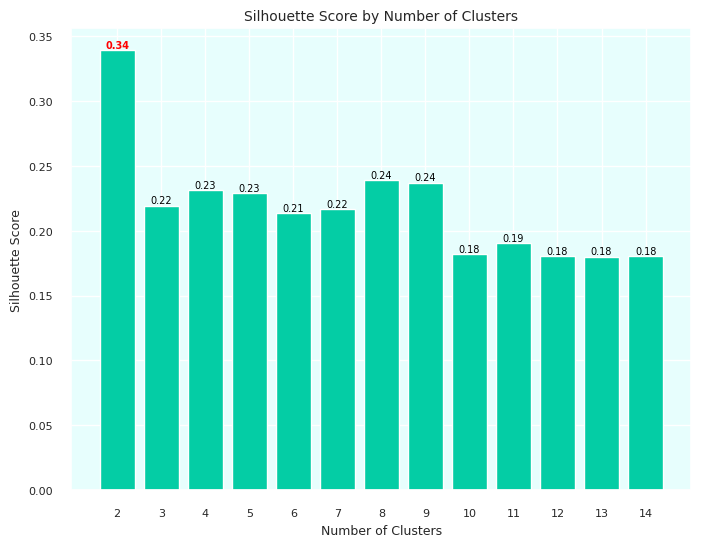

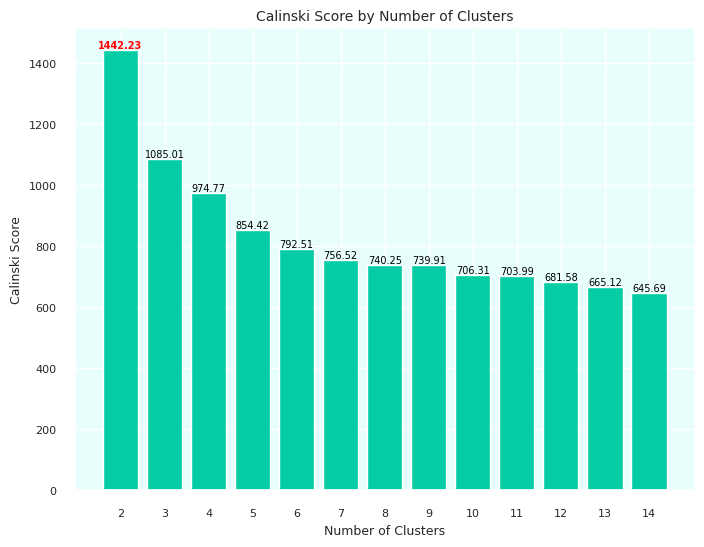

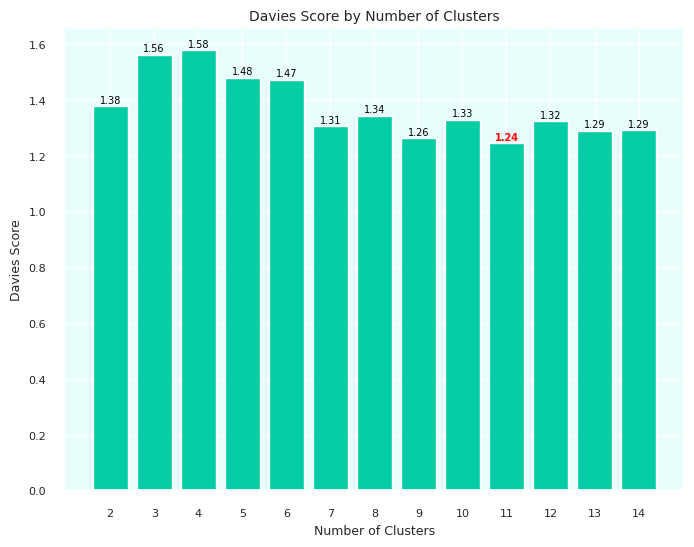

In [56]:
for score, metric, mode in [(silhouette, "Silhouette", "max"), (calinski, "Calinski", "max"), (davies, 'Davies', "min")]:
    getClusterMetricPlot(score, metric, mode)

<div style="border-radius:10px; font-size:120%; padding:15px; color:#4D5456; background-color:#E6FEFF"> 

By observing each of **Cluster Evaluation Metrics** plot, we can infer that optimal `n_cluster` is **2**. Split Customers into **Low Spender** and **High Spender**.

But I want more information from created clusters that is why my preference is `n_cluster`  between **3-5**. I would like to go with `n_cluster` as **4** as it has Decent **Distortion Score**, Manageable **Silhouette Score**, Good **Calinski-Herbasz Score**, Decent **Davies-Bouldin Score** and let us clustered our customers into **Active Low Spender**, **Not Active Very Low Spender**, **Big Spenders** and **Low-to-Medium Spenders** which in return enhances our recommendation pipeline.

In [57]:
CLUSTERS = 4

In [58]:
kmeans = KMeans(n_clusters = CLUSTERS, init="k-means++", n_init=20, max_iter=300, random_state=44)
kmeans.fit(pca_df)
clusters = kmeans.predict(pca_df)
scaled_df.loc[:, "Cluster"] = clusters

In [59]:
cluster_count_dict = scaled_df.loc[:, "Cluster"].value_counts().to_dict()
scaled_df.loc[:, "ClusterCount"] = scaled_df.loc[:, "Cluster"].map(cluster_count_dict)
scaled_df.loc[:, "Cluster"] = scaled_df.loc[:, "ClusterCount"].transform("rank", method="dense")-1
scaled_df.drop(columns = "ClusterCount", inplace = True)

In [60]:
cluster_count = scaled_df.groupby("Cluster").size()

In [61]:
COLORS = ["#FF3305", "#FF9305", "#9FFF05", "#05FFB0"]

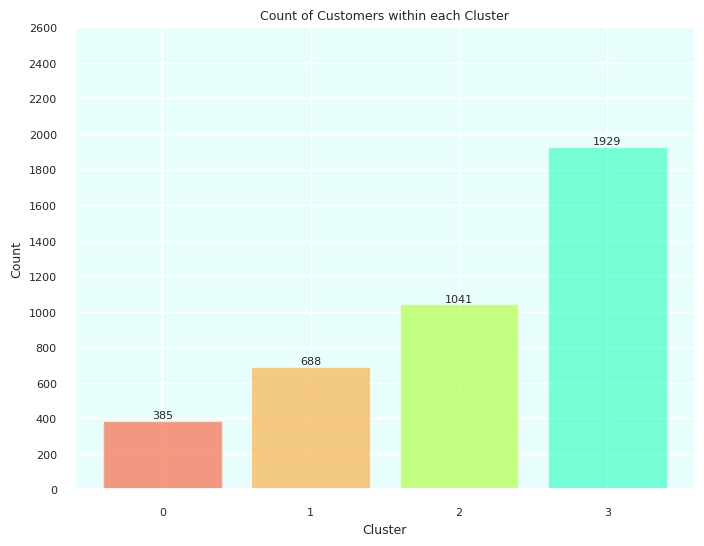

In [62]:
fig = plt.figure(figsize = (8, 6))

plt.bar(x = cluster_count.index, height=cluster_count, color=COLORS, alpha=.5)

plt.xticks(range(len(cluster_count)))
plt.yticks(range(0, 2700, 200))

for i in range(len(cluster_count)):
    plt.text(cluster_count.index[i], cluster_count.iloc[i]+15, f"{cluster_count.iloc[i]:.0f}", fontsize=8, ha="center")

plt.tick_params(axis="both", which="major", labelsize=8)
plt.title("Count of Customers within each Cluster", fontsize=9)
plt.xlabel("Cluster", fontsize=9)
plt.ylabel("Count", fontsize=9)
plt.show()

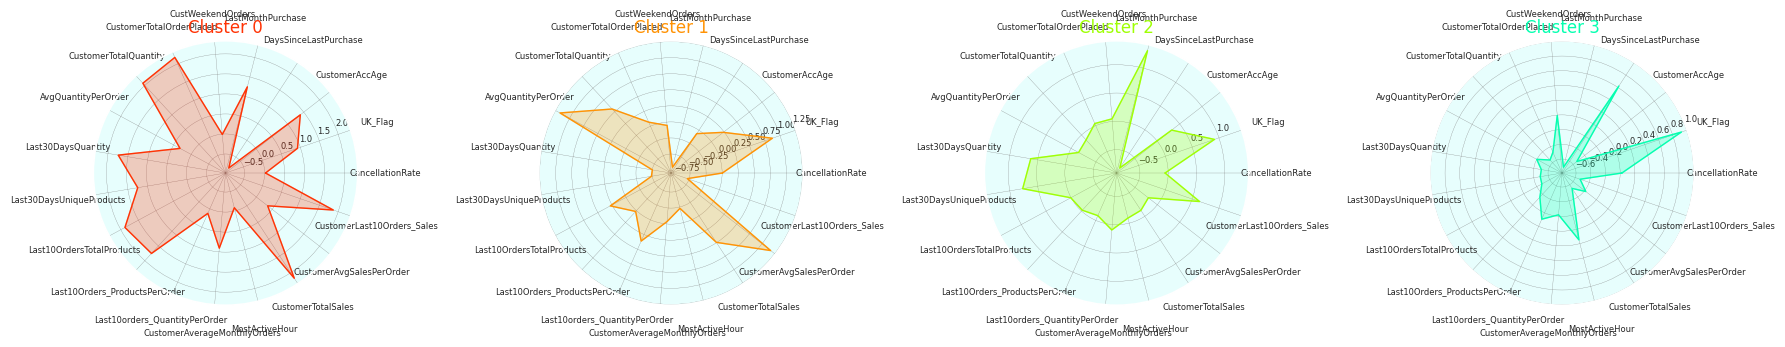

In [63]:
fig, ax = plt.subplots(1, CLUSTERS, figsize=(18, 14), subplot_kw={"polar":True})

for idx in range(CLUSTERS):
    
    angles = [i for i in np.linspace(0, 2*np.pi, scaled_df.shape[1]-1, endpoint=False)]
    angles.append(angles[0])
    
    means = scaled_df.groupby("Cluster").mean().iloc[idx].to_list()
    means.append(means[0])
    
    ax[idx].fill(angles, means, alpha=.25, color=COLORS[idx])
    ax[idx].plot(angles, means, linewidth=1, linestyle="solid", color=COLORS[idx])
    
    ax[idx].set_xticks(angles[:-1])
    ax[idx].set_xticklabels([i for i in scaled_df.columns][:-1], fontsize=6)
    
    ax[idx].set_title(f"Cluster {idx:.0f}", color=COLORS[idx])
    ax[idx].grid(color="grey", linewidth=.2)
    ax[idx].tick_params(axis="both", which="major", labelsize=6)

plt.tight_layout()
plt.show()

<div style="border-radius:10px; font-size:120%; padding:15px; color:#4D5456; background-color:#E6FEFF">
    
<font color="FF3305" size=4px>**Cluster 0: Loyal, Very Active, High Spenders and Most Valuable Customers**</font>

- This Customers are Very Active (**Low** 'Days Since Last Purchase'), Loyal (**High** `Account Age` and `Average Monthly Sales`), **High** Spender (Very High `Total Sales` and `Total Orders`) with **Medium**`Cancellation Rate`.
- They purchase variety of products as shown by `Last 30 Days Unique Products` and `Last 10 orders Product per Order`, making them perfect candidate for recommending variety of items.
- They Have **Medium** `Average Quantity Per Order` and `Average Sales Per Order` but since they have **Very High** `Total Sales` we can infer that they they like to purchase **Medium-to-High** `UnitPrice` items thus providing us another reason for targeted product recommendation.
- **50%** of this customers like to purchase during `Weekend` and more than **90%** of this customers are from `United Kingdom`.

<div style="border-radius:10px; font-size:120%; padding:15px; color:#4D5456; background-color:#E6FEFF">
    
<font color="FF9305" size=4px>**Cluster 1: Medium-to-High Spenders, Recently Churning**</font>

- This set of clusters have **Medium** `Account Age` and **Low-to-Medium** `Days Since Last Purchase` which tell us that recently (Last Month or even before) they have not been transacting.
- When they have Medium `Total sales` and `Quantity` but **Very High** `Average Sales per Order` and `Average Quantity per Order`. This are the customers who likes to buy in Bulk so if we make them transact more there sales will increase significantly.
- They have **Low-to-Medium** `Cancellation Rate` which means they are product/quality conscious and mostly (**Medium-to-High** %) from `United Kingdom`.
- They like to transact around `10AM - 11AM` and during `WorkDays`.

<div style="border-radius:10px; font-size:120%; padding:15px; color:#4D5456; background-color:#E6FEFF">

<font color="81D100" size=4px>**Cluster 2: Very Active Low Spender**</font>

- Customers who have made a transaction recently, have **Medium** `Account Age` and **Very High** `Transaction Rate` from `Last Month` and bought many different products.
- They have **Medium** `Cancellation Rate` which tells us about them that they are very conscious about the product/quality.
- They have **Low-to-Medium** `Total Sales` but from this customers we have **Low-to-Medium** `Total Sales` from their `Last 30 days` which tell us that they will most likely going to transact more in the future.
- This customer are from Mostly from United Kingdom and the rest are from Other Countries.
- Most of them like to transact around `10AM - 12PM` and another Good thing about this set of customers is that the rest of their transaction attributes falls in the range of **Low-to-Medium**.

<div style="border-radius:10px; font-size:120%; padding:15px; color:#4D5456; background-color:#E6FEFF">
    
<font color="#00D18B" size=4px>**Cluster 3: Inactive Very Low Spenders**</font>

- This set of customers have **Very Low** `Transaction Rate` and they are Highly `Inactive` as they have no transactions recently even though their `Account Age` is **Low**.
- The have **Very Low** `Total Sales`, `Total Quantity` and have **Low-to-Medium** `Weekend Transactions` and `Cancellation Rate` as well.
- They Like to Transact around `1PM` and Bad thing about this set of customer is that they comprises of more than 40% of total customer count and most of their transaction attributes falls in **Low** category.
- They are mostly (**High** %) from `United Kingdom`.

In [64]:
cust_cluster_map = {i:c for i, c in zip(scaled_df.index, scaled_df.Cluster)}

<div style="border-radius:10px; font-size:120%; padding:15px; color:#4D5456; background-color:#E6FEFF"> 
    
<h1 align = "center"><font color="red">Recommendation Systems (RecSys)</font></h1>

Now that I have segmented our customers we would like to recommend them some items for their next order. One way we can do this by just getting list of most popular items within the cluster of customers and recommend those items to the customers.

But I would like to implement Traditional **Popularity Based Recommendation System & Collaborative Filtering** and would like to evaluate based on **Recall@topn** metric to know which Recommendation System is performing better.

In [65]:
CustomerStocks = df.groupby(["CustomerID", "InvoiceNo"])["StockCode"].nunique().reset_index()
CustomerStocks =CustomerStocks.groupby("CustomerID")["StockCode"].mean()
CustomerStocks = CustomerStocks[CustomerStocks>=5]
selected_customers = CustomerStocks.index
len(selected_customers)

3905

In [66]:
rec_df = df[df.CustomerID.isin(selected_customers)].copy()
rec_df.drop(columns=["InvoiceDate", "CancellationRate", "UK_Flag", "InvoiceNo"], inplace=True)
rec_df.head(5)

,StockCode,Description,Quantity,UnitPrice,CustomerID,Country
0,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2.55,17850.0,United Kingdom
1,71053,WHITE METAL LANTERN,6,3.39,17850.0,United Kingdom
2,84406B,CREAM CUPID HEARTS COAT HANGER,8,2.75,17850.0,United Kingdom
3,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,3.39,17850.0,United Kingdom
4,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,3.39,17850.0,United Kingdom


In [67]:
popular_stocks =rec_df.groupby("StockCode")["CustomerID"].nunique()\
.sort_values(ascending=False).reset_index().rename(columns={"CustomerID":"Popularity"})
popular_stocks.head(5)

,StockCode,Popularity
0,22423,854
1,85123A,833
2,47566,686
3,84879,667
4,22720,635


<div style="border-radius:10px; font-size:120%; padding:15px; color:#4D5456; background-color:#E6FEFF"> 
    
<h2 align = "center"><font color="red">Train Test Split</font></h2>

Since we want to evaluate our models, we will create a train-test split of 80:20 ratio. For reproducibility I will provide a `random_state=44` and will make sure all users that is in train set also available in test set by providing `stratify=CustomerID`.

In [68]:
stratify="CustomerID"

train_df, test_df = train_test_split(
    rec_df,
    test_size=.2,
    random_state=44,
    shuffle=True,
    stratify=rec_df[stratify]
)

train_df.shape, test_df.shape

((308905, 6), (77227, 6))

In [69]:
ALL_STOCKS = set(rec_df["StockCode"].unique())

<div style="border-radius:10px; font-size:120%; padding:15px; color:#4D5456; background-color:#E6FEFF"> 
    
<h1 align = "center"><font color="red">Popularity Based Recommendation System</font></h1>

**Popularity Based RecSys** provides recommendation based upon how popular items. You will be surprised to know that such simple RecSys can be quite powerful and easier to implement as they themselves don't require any complex calculations just like in **Content-Based and Collaborative Filtering RecSys**.

Here I will implement 2 **Popularity Based RecSys**:
1. **Cluster Based Popularity RecSys**, Which recommends items for users based upon their clusters that we have found previously.
2. Then I will implement Traditional **Popularity Based RecSys** which recommends based upon most popular items of entire user-base.

In [70]:
cluster_df = rec_df.copy()
cluster_df["Cluster"] = rec_df["CustomerID"].map(cust_cluster_map)
cluster_df.dropna(subset="Cluster", inplace=True)
cluster_df.head(5)

,StockCode,Description,Quantity,UnitPrice,CustomerID,Country,Cluster
9,84879,ASSORTED COLOUR BIRD ORNAMENT,32,1.69,13047.0,United Kingdom,1.0
10,22745,POPPY'S PLAYHOUSE BEDROOM,6,2.10,13047.0,United Kingdom,1.0
11,22748,POPPY'S PLAYHOUSE KITCHEN,6,2.10,13047.0,United Kingdom,1.0
12,22749,FELTCRAFT PRINCESS CHARLOTTE DOLL,8,3.75,13047.0,United Kingdom,1.0
13,22310,IVORY KNITTED MUG COSY,6,1.65,13047.0,United Kingdom,1.0


In [71]:
cluster_stocks = cluster_df.groupby(["Cluster", "StockCode"])["CustomerID"].nunique()\
.reset_index().rename(columns={"CustomerID":"Popularity"})

cluster_pop_dict = {
    0: cluster_stocks[cluster_stocks["Cluster"]==0].sort_values(by="Popularity", ascending=False),
    1: cluster_stocks[cluster_stocks["Cluster"]==1].sort_values(by="Popularity", ascending=False),
    2: cluster_stocks[cluster_stocks["Cluster"]==2].sort_values(by="Popularity", ascending=False),
    3: cluster_stocks[cluster_stocks["Cluster"]==3].sort_values(by="Popularity", ascending=False),
}

cluster_customers = cluster_df.CustomerID.unique()

<div style="border-radius:10px; font-size:120%; padding:15px; color:#4D5456; background-color:#E6FEFF"> 
    
<h2 align = "center"><font color="red">Utility Functions</font></h2>

Some Utility Functions that will be used in our RecSys pipelines.

In [72]:
def getCustomerTestInteractions(custId):
    cust_test_interactions = set(test_df[test_df["CustomerID"]==custId].StockCode)
    return cust_test_interactions

def getNonInteractions(custId):
    interactions = set(train_df[train_df["CustomerID"]==custId].StockCode)
    non_interactions = ALL_STOCKS - interactions
    return non_interactions

def getRandomInteractions(non_interactions, random_size, seed):
    random.seed(seed)
    random_interactions = random.sample(list(non_interactions), random_size)
    return random_interactions

def getHitFlag(sorted_predictions, stockCode, topN):
    hit = stockCode in set(sorted_predictions.iloc[:topN]["StockCode"])
    return hit

In [73]:
random_size = 100

def EvaluatePopularityModel(random_size, clusterModel=True):
    RecallAt5 = []
    RecallAt10 = []
    global popular_stocks

    if clusterModel:
        print(f"Loading Cluster Based Popularity Model for {len(cluster_customers)} customers.")
    else:
        print(f"Loading Popularity Model for {len(selected_customers)}")

    for custId in tqdm(test_df["CustomerID"].unique(), desc="Loading: "):
        
        if clusterModel:
            if (custId not in cluster_customers): continue
            else:
                popular_stocks = cluster_pop_dict[cust_cluster_map[custId]]
        
        cust_test_interactions = getCustomerTestInteractions(custId)
        non_interactions = getNonInteractions(custId)
        
        hitAt5 = 0
        hitAt10 = 0
        
        for seed, stockCode in enumerate(cust_test_interactions):
            random_interactions = getRandomInteractions(non_interactions, random_size, seed)
            random_interactions.append(stockCode)
            sorted_predictions = popular_stocks[popular_stocks.StockCode.isin(random_interactions)]
            hitAt5 += getHitFlag(sorted_predictions, stockCode, 5)
            hitAt10 += getHitFlag(sorted_predictions, stockCode, 10)
    
        RecallAt5.append(hitAt5 / (seed+1))
        RecallAt10.append(hitAt10 / (seed+1))

    return np.mean(RecallAt5), np.mean(RecallAt10)

In [74]:
ClusterRecallAt5, ClusterRecallAt10 = EvaluatePopularityModel(random_size, clusterModel=True)
ClusterRecallAt5, ClusterRecallAt10

Loading Cluster Based Popularity Model for 3654 customers.


Loading:   0%|          | 0/3905 [00:00<?, ?it/s]

(np.float64(0.31829912421991363), np.float64(0.4746131845908012))

In [75]:
PopularityRecallAt5, PopularityRecallAt10 = EvaluatePopularityModel(random_size, clusterModel=False)
PopularityRecallAt5, PopularityRecallAt10

Loading Popularity Model for 3905


Loading:   0%|          | 0/3905 [00:00<?, ?it/s]

(np.float64(0.30056151888665184), np.float64(0.4537058871409479))

<div style="border-radius:10px; font-size:120%; padding:15px; color:#4D5456; background-color:#E6FEFF"> 
    
<h1 align="center"><font color="red">Collaborative Filtering</font></h1>

Now I will create **Collaborative Filtering Recommendation System** where I will use **Singular Value Decomposition** to reconstruct original matrix which is capable of providing details about how relevant a product is to a customer based on all customers.

In [76]:
train_df["Sales"] = train_df["Quantity"] * train_df["UnitPrice"]

grouped = train_df.groupby(["CustomerID", "StockCode"])["Sales"].sum().reset_index()

cf_matrix = grouped.pivot(
    index="CustomerID", 
    columns="StockCode",
    values="Sales"
).fillna(0)

cf_matrix.head(5)

StockCode,10002,10080,10120,10123C,10124A,10124G,10125,10133,10135,11001,...,90214O,90214P,90214R,90214S,90214T,90214U,90214V,90214W,90214Y,90214Z
CustomerID,,,,,,,,,,,,,,,,,,,,,
12347.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
12348.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
12349.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
12350.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
12352.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


<div style="border-radius:10px; font-size:120%; padding:15px; color:#4D5456; background-color:#E6FEFF"> 
    
<h2 align = "center"><font color="red">Applying SVD</font></h2>

Now I will apply **SVD** on `cf_matrix` to reconstruct original matrix which is now transformed.

In [77]:
# Number of Components for SVD 

n_components = 25

In [78]:
U, sigma, Vt = svds(
    cf_matrix.values,
    k=n_components
)

In [79]:
print(f"Shape of U:     {U.shape}")
print(f"Shape of Sigma: {sigma.shape}")
print(f"Shape of Vt:    {Vt.shape}")

Shape of U:     (3905, 25)
Shape of Sigma: (25,)
Shape of Vt:    (25, 3613)


In [80]:
sigma = np.diag(sigma)

In [81]:
svd_matrix = np.dot(np.dot(U, sigma), Vt)
svd_matrix.shape

(3905, 3613)

In [82]:
svd_matrix = (svd_matrix - svd_matrix.min()) / (svd_matrix.max() - svd_matrix.min())

In [83]:
svd_df = pd.DataFrame(
    data=svd_matrix, 
    columns=cf_matrix.columns,
    index=cf_matrix.index
).T

svd_df.head(5)

CustomerID,12347.0,12348.0,12349.0,12350.0,12352.0,12354.0,12355.0,12356.0,12357.0,12358.0,...,18272.0,18274.0,18276.0,18277.0,18278.0,18280.0,18281.0,18282.0,18283.0,18287.0
StockCode,,,,,,,,,,,,,,,,,,,,,
10002,0.038508,0.038489,0.038494,0.038490,0.038496,0.038489,0.038489,0.038496,0.038502,0.038499,...,0.038485,0.038489,0.038493,0.038491,0.038490,0.038489,0.038490,0.038490,0.038488,0.038493
10080,0.038490,0.038489,0.038489,0.038489,0.038489,0.038489,0.038489,0.038489,0.038490,0.038489,...,0.038489,0.038489,0.038489,0.038489,0.038489,0.038489,0.038489,0.038489,0.038490,0.038489
10120,0.038490,0.038489,0.038489,0.038489,0.038489,0.038489,0.038489,0.038489,0.038489,0.038489,...,0.038489,0.038489,0.038489,0.038489,0.038489,0.038489,0.038489,0.038489,0.038489,0.038489
10123C,0.038489,0.038489,0.038489,0.038489,0.038489,0.038489,0.038489,0.038489,0.038489,0.038489,...,0.038489,0.038489,0.038489,0.038489,0.038489,0.038489,0.038489,0.038489,0.038489,0.038489
10124A,0.038489,0.038489,0.038489,0.038489,0.038489,0.038489,0.038489,0.038489,0.038489,0.038489,...,0.038489,0.038489,0.038489,0.038489,0.038489,0.038489,0.038489,0.038489,0.038489,0.038489


In [84]:
cust_mapping = {k:v for v, k in enumerate(cf_matrix.index)}

In [85]:
def EvaluateCollaborativeModel(random_size, matrix):
    RecallAt5 = []
    RecallAt10 = []
    
    for custId in tqdm(test_df["CustomerID"].unique(), desc="Loading: "):
        cust_test_interactions = getCustomerTestInteractions(custId)
        non_interactions = getNonInteractions(custId)
        cust_cf_rec = matrix[custId].copy()
        cust_cf_rec = cust_cf_rec.sort_values(ascending=False)
        cust_cf_rec = cust_cf_rec.reset_index().rename(columns={"index":"StockCode"})
        hitAt5 = 0
        hitAt10 = 0
        
        for seed, stockCode in enumerate(cust_test_interactions):
            random_interactions = getRandomInteractions(non_interactions, random_size, seed)
            random_interactions.append(stockCode)
            sorted_predictions = cust_cf_rec[cust_cf_rec.StockCode.isin(random_interactions)]
            hitAt5 += getHitFlag(sorted_predictions, stockCode, 5)
            hitAt10 += getHitFlag(sorted_predictions, stockCode, 10)
    
        RecallAt5.append(hitAt5 / (seed+1))
        RecallAt10.append(hitAt10 / (seed+1))

    return np.mean(RecallAt5), np.mean(RecallAt10)

In [86]:
CFRecallAt5, CFRecallAt10 = EvaluateCollaborativeModel(random_size, svd_df)
CFRecallAt5, CFRecallAt10

Loading:   0%|          | 0/3905 [00:00<?, ?it/s]

(np.float64(0.32670840895494346), np.float64(0.4512861454405147))

<div style="border-radius:10px; font-size:120%; padding:15px; color:#4D5456; background-color:#E6FEFF"> 
    
<h2 align = "center"><font color="red">Visualizing Implemented RecSys results</font></h2>


In [87]:
results_df = pd.DataFrame(
    data = {
        "models" : ["Cluster Popularity", "Popularity", "Collaborative",
                   "Cluster Popularity", "Popularity", "Collaborative"],

        "scores" : [ClusterRecallAt5, PopularityRecallAt5, CFRecallAt5,
                    ClusterRecallAt10, PopularityRecallAt10,CFRecallAt10],

        "metrics" : ["Recall@5", "Recall@5", "Recall@5",
                   "Recall@10", "Recall@10", "Recall@10",]
    }
)

In [88]:
# Mapping numeric to each model according to their position in `models_score_df`

models_x_values = {
    
    "Cluster Popularity": 0,
    "Popularity"        : 1,
    "Collaborative"     : 2,
    
}

In [89]:
# Colors used for Plots

BG_COLOR = "#E7FEFD"
bar_colors = [MISC_COLOR, MISC_COLOR2]
sns.set(rc={"axes.facecolor": BG_COLOR}, style="darkgrid")

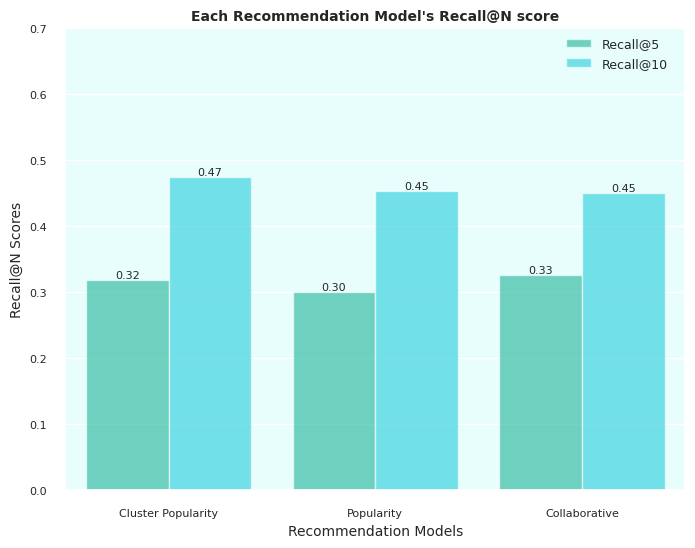

In [90]:

fig, ax = plt.subplots(figsize=(8,6))
bar = sns.barplot(data=results_df, x="models", y="scores", hue="metrics", alpha=.6, palette=bar_colors)

for i, (m, s) in  enumerate(zip(results_df["models"], results_df["scores"])):
    offset = -.2 if i<=len(models_x_values)-1 else .2
    plt.text(models_x_values[m] + offset, y=s+.003, s= f"{s:.2f}", ha="center", fontsize=8)

plt.yticks([i/10 for i in range(8)])
plt.xlabel("Recommendation Models", fontsize=10)
plt.ylabel("Recall@N Scores", fontsize=10)
plt.tick_params(axis="both", which="major", labelsize=8)
plt.title("Each Recommendation Model's Recall@N score", fontweight="bold", fontsize=10)

plt.legend(
    handles = [bar.patches[0], bar.patches[len(models_x_values)]],
    labels = ["Recall@5", "Recall@10"],
    loc = (.8, .9),
    fontsize = 9,
    edgecolor = "grey",
)

plt.show()

<div style="border-radius:10px; font-size:120%; padding:15px; color:#4D5456; background-color:#E6FEFF"> 
    
<h1 align = "center"><font color="red">Recommendation System Results</font></h1>

So I have implemented 3 different RecSys models and all produce very similar results where **Cluster Based Popularity Model** gives highest **Recall@10** **(~.46)**, whereas **Collaborative Filtering** gives highest **Recall@5** **(~.32)** and **Traditional Popularity Model** results in in between **Collaborative Filtering & Cluster Based Popularity**.